In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/sales_clean.csv")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,region,product_id,category,sub-category,product_name,sales,quantity,profit,returns,payment_mode
0,CA-2019-160304,2019-01-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.94,1,28.2668,No,Online
1,CA-2019-160304,2019-02-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.94,3,38.2668,No,Online
2,CA-2019-160304,2019-02-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,TEC-PH-10000455,Technology,Phones,GE 30522EE2,231.98,2,67.2742,No,Cards
3,CA-2019-125206,2019-03-01,2019-05-01,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,California,West,OFF-ST-10003692,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.46,2,28.6150,No,Online
4,US-2019-116365,2019-03-01,2019-08-01,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,Texas,Central,TEC-AC-10002217,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.08,2,-5.2640,No,Online


In [6]:
df["order_date"] = pd.to_datetime(df["order_date"])

sales_over_time = (
    df.groupby(df["order_date"].dt.to_period("M"))["sales"]
    .sum()
    .reset_index()
)

sales_over_time["order_date"] = sales_over_time["order_date"].astype(str)


In [9]:
sales_over_time.head()

,order_date,sales
0,2019-01,38122.1240
1,2019-02,25538.4100
2,2019-03,49612.0450
3,2019-04,45192.2780
4,2019-05,57964.3218


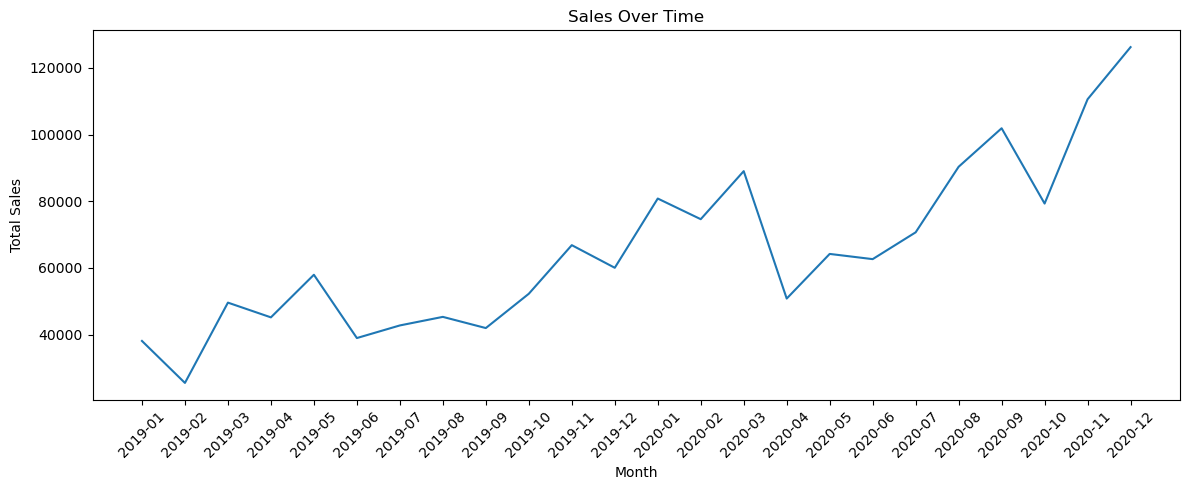

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(sales_over_time["order_date"], sales_over_time["sales"])
plt.xticks(rotation=45)
plt.title("Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()


In [10]:
top_products = (
    df.groupby("product_name")["profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


In [11]:
top_products.head()

product_name
Canon imageCLASS 2200 Advanced Copier                        25199.9280
Hewlett Packard LaserJet 3310 Copier                          6407.8932
3D Systems Cube Printer, 2nd Generation, Magenta              3717.9714
HP Designjet T520 Inkjet Large Format Printer - 24" Color     2799.9840
GBC DocuBind TL300 Electric Binding System                    2753.7593
Name: profit, dtype: float64

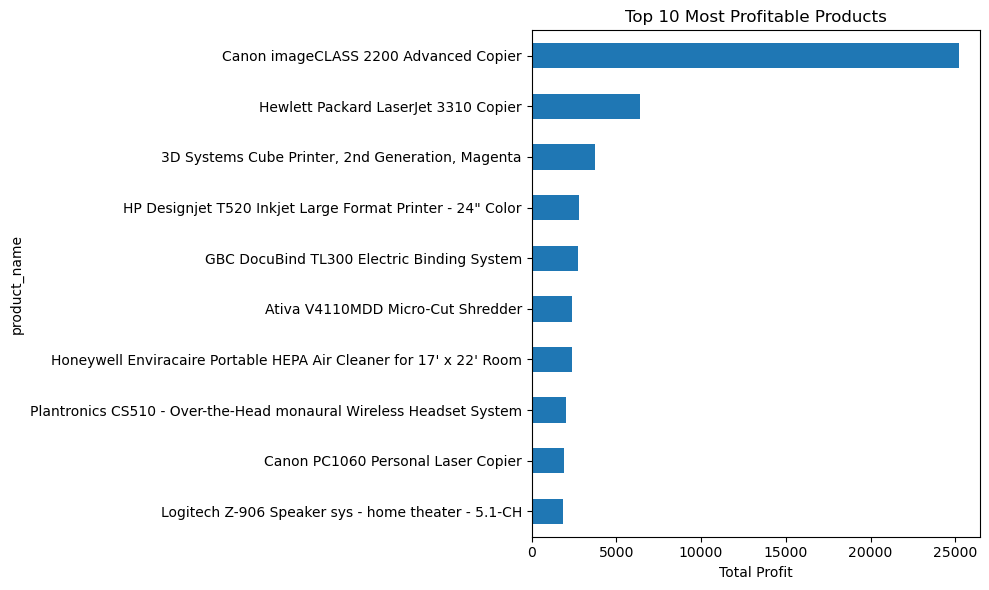

In [13]:
plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 Most Profitable Products")
plt.xlabel("Total Profit")
plt.tight_layout()
plt.show()


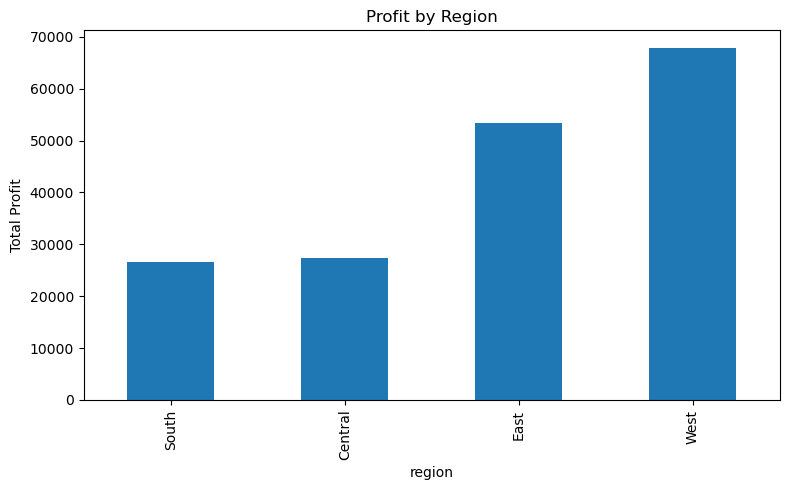

In [16]:
profit_by_region = df.groupby("region")["profit"].sum().sort_values()

plt.figure(figsize=(8,5))
profit_by_region.plot(kind="bar")
plt.title("Profit by Region")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()


In [17]:
pivot = pd.pivot_table(
    df,
    values="profit",
    index="region",
    columns="category",
    aggfunc="sum"
)


In [18]:
pivot.head()

category,Furniture,Office Supplies,Technology
region,,,
Central,-1534.7880,6477.6297,22507.1654
East,3621.5039,23248.6104,26530.3100
South,2562.0203,11104.9759,12884.7201
West,5357.8750,33966.0301,28536.0531


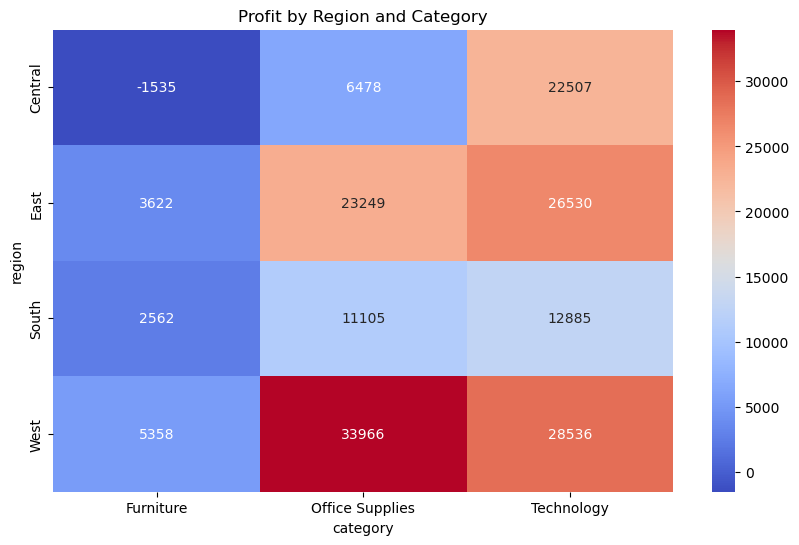

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Profit by Region and Category")
plt.show()
